### Load in RNA Data

Loads CosMX RNA expression data. Will take several minutes

In [63]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

TMA_Core="A" # Should be A,B,C 

#Load files on laptop
expr= pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
#expr=expr_orig.transpose()
metadata = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
umap = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

# Extra - MetaData File
extra_metadata=pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\Run_TMA{TMA_Core}_metadata_file.csv", index_col=0)

# Create AnnData object
adata_rna = sc.AnnData(X=expr.values)

# Assign metadata
adata_rna.obs = metadata
adata_rna.var_names = expr.columns
adata_rna.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata_rna.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata_rna.obsm["X_umap"] = umap.values

### Load in Ligand and Receptor pairs

In [69]:
def check_expression(ligand, receptor_list, expr):
    """
    Case-insensitive check.
    Also returns the ligand and receptor names
    in the correct case as stored in expr.columns.
    """

    # Mapping: lowercase → original column name
    expr_map = {col.lower(): col for col in expr.columns}

    # Check ligand
    ligand_lower = ligand.lower()
    ligand_ok = ligand_lower in expr_map
    ligand_corrected = expr_map.get(ligand_lower, None)

    # Check receptors & return corrected names
    receptors_ok = True
    corrected_receptors = []

    for g in receptor_list:
        g_lower = g.lower()
        if g_lower in expr_map:
            corrected_receptors.append(expr_map[g_lower])
        else:
            receptors_ok = False
            corrected_receptors.append(None)  # or keep original

    return ligand_ok, receptors_ok, ligand_corrected, corrected_receptors


# Load files on laptop
LR_pairs = pd.read_csv(fr"C:\Users\evanj\Documents\Din Lab Data Files\cellchat_LR_pairs.csv", index_col=0)

# Convert ligand + receptor columns to NumPy array
lr_array = LR_pairs[["ligand", "receptor"]].to_numpy()

num_false=0
num_true=0

for i in range(1939):
    ligand = lr_array[i, 0]
    receptor = lr_array[i, 1]

    if not ligand_ok or not receptors_ok:
        num_false=num_false+1
    else:
        num_true=num_true+1
        

    # Convert receptor string to list
    receptor_list = receptor.split("_")

    # Check if they exist in expr.columns
    ligand_ok, receptors_ok, ligand_corrected, corrected_receptors = check_expression(ligand, receptor_list, expr)

    # print(f"Ligand: {ligand}, OK: {ligand_ok}")
    # print(f"Receptors: {ligand_corrected}, OK: {corrected_receptors}")
    # print(f"Receptors: {ligand}, OK: {receptor_list}")
    # print("----------")

display(f"num true {num_true}")
display(f"num false {num_false}")

'num true 374'

'num false 1565'

### Functions

In [46]:
def get_interaction_status_mRNA(adata_rna, sample_id, distance_threshold, target_cell_type, cell_type_1, sender_genes, reciever_genes):
    """
    Determine whether a particular cell group is interacting with one or two other cell groups.

    Parameters
    ----------
    adata : AnnData
        Annotated data object with spatial transcriptomics or single-cell data.
    sample_id : str
        Identifier for the sample to analyze within `adata`.
    distance_threshold : float
        Distance in microns to define interaction.
    target_cell_type : str
        Cell type to check interactions for.
    cell_type_1 : str, optional
        First target cell type to assess interaction with (default: "Neutrophil").
    cell_type_2 : str, optional
        Second target cell type to assess interaction with (default: "NA").

    Returns
    -------
    dict
        Contains:
        - "Interaction Matrix": pandas.DataFrame with interaction booleans and status labels.
    """
    import pandas as pd

    # Get distance matrix for cell_type_1
    results_1 = nearest_cells_of_particular_type_mRNA(adata_rna, sample_id, target_cell_type, cell_type_1,sender_genes, reciever_genes)["Distance Matrix"]
    threshold = distance_threshold

    output = pd.DataFrame(index=results_1.index)
    output[f'{cell_type_1} Interacting'] = results_1['Minimum Distance'] <= threshold

    # Classify into two categories
    def classify(row):
        if row[f'{cell_type_1} Interacting']:
            return 'Interacting'
        else:
            return 'Not Interacting'

    output['Interaction_Status'] = output.apply(classify, axis=1)

    return {
        "Interaction Matrix": output
    }

def nearest_cells_of_particular_type_mRNA(adata_rna,sample_ID,orgin_cell_types,cell_distance_types,sender_genes,reciever_genes):
    """
    Calculates distance matrix between PMNs and target cells of a particular type,
    along with summary statistics.

    Parameters:
    -----------
    adata : AnnData
        Annotated data object containing spatial information for cells.
    sample_ID : str
        Identifier for the specific sample to analyze.
    orgin_cell_type : str
        The string name of the orgin cell specified. This will mostly commonly be neutrophils
    cell_distance_type : str
        Cell type to use as the target for distance calculations (e.g., "CD4+T_cells").

    Returns:
    --------
    dict
        A dictionary containing:
        - 'Distance Matrix' (pd.DataFrame): Matrix of distances between orgin and target cells,
          including additional columns for 'Minimum Distance' and 'Average Distance' per orging cell.
        - 'Average Distance' (float): Overall average distance across the entire matrix.
        - 'Average Mininum Distance' (float): Average of each orgin cell's minimum distance to target cells.
    """
    import pandas as pd

    # Creates lists of cell types for PMN and the target comparison
    orgin_cell_type_list = gene_expression_cell_list(adata_rna,sample_ID,sender_genes,orgin_cell_types)
    target_cell_list = gene_expression_cell_list(adata_rna,sample_ID,reciever_genes,cell_distance_types)
    
    # Initialize results storage: one column for this cell type
    distance_matrix = pd.DataFrame(index=orgin_cell_type_list, columns=target_cell_list)
    
    for pmn in orgin_cell_type_list:
        for target_cell in target_cell_list:
            distance_matrix.loc[pmn,target_cell]=find_distance_mRNA(adata_rna,pmn, target_cell)["Distance um"]
    
    # Ensure numeric types
    distance_matrix = distance_matrix.apply(pd.to_numeric, errors='coerce')
    
    # Calculate overall average distance across entire matrix
    overall_avg_distance = distance_matrix.mean().mean()

    # Calculate average mininum distance
    average_min_distance = distance_matrix.min(axis=1).mean()
            
    # Add columns first (unrounded)
    distance_matrix['Minimum Distance'] = distance_matrix.min(axis=1).round(2)
    distance_matrix['Average Distance'] = distance_matrix.mean(axis=1).round(2)
    
    return{
        "Distance Matrix":distance_matrix,
        "Average Distance":overall_avg_distance,
        "Average Mininum Distance": average_min_distance
    }
    
def gene_expression_cell_list(adata_rna, name_string, gene_targets, cell_filter_list):
    """
    Retrieve the list of cells that express any of the given genes and match cell type criteria.
    
    Parameters:
    - adata_rna: AnnData object
    - name_string: The name of the punch without the cell number. Ex "c_1_1"
    - gene_targets: List of genes being targeted in the expression file
    - cell_filter_list: List of cell types (annot_cluster_2) to include in results
    
    Returns:
    - List of cell IDs that meet the gene expression and cell type criteria
    """

    # Ensure gene_targets is a list
    if isinstance(gene_targets, str):
        gene_targets = [gene_targets]

    # Subset by tma_fov_id
    adata_sub = adata_rna[adata_rna.obs["tma_fov_id"] == name_string].copy()

    # Filter by cell type
    if cell_filter_list:
        adata_sub = adata_sub[adata_sub.obs["annot_cluster2"].isin(cell_filter_list)].copy()

    # Ensure all genes exist
    missing_genes = [g for g in gene_targets if g not in adata_sub.var_names]
    if missing_genes:
        raise ValueError(f"Genes not found: {missing_genes}")

    # Get expression values for all genes
    expr_values = adata_sub[:, gene_targets].X

    # Convert sparse to dense if needed
    if hasattr(expr_values, "toarray"):
        expr_values = expr_values.toarray()

    # Keep cells where ANY gene has expression > 0
    mask = (expr_values > 0).any(axis=1)

    # Return matching cell IDs
    return adata_sub.obs.index[mask].tolist()

def get_xy_coords_mRNA(adata_rna,cell_ID):
    """
    Retrieve the XY pixel coordinates for a given cell.
    Parameters:
    ----------
    adata : AnnData
    cell_ID : str
        Unique identifier for the cell.
    Returns:
    -------
    dict
        Dictionary containing:
        - "X": X-coordinate in pixels (int)
        - "Y": Y-coordinate in pixels (int)
    """
    x_coord=adata_rna.obs.loc[cell_ID, "x_pixel"]
    y_coord=adata_rna.obs.loc[cell_ID, "y_pixel"]
    
    return{
        "X":x_coord,
        "Y":y_coord
    }
    
def find_distance_mRNA(adata_rna,cell_ID_1,cell_ID_2,unit_conversion=0.168):
    """
    Calculate the Euclidean distance between two cells based on their XY coordinates.
    Parameters:
    ----------
    cell_ID_1 : str
        Unique identifier for the first cell.
    cell_ID_2 : str
        Unique identifier for the second cell.
    unit_conversion : float, optional
        Conversion factor from pixels to microns. Default is 0.168 µm/px.

    Returns:
    -------
    dict
        Dictionary containing:
        - "Distance px": Distance between cells in pixels (float)
        - "Distance um": Distance between cells in microns (float)
    """
    from math import sqrt
    # Get Cell Locations
    cell_1_xy=get_xy_coords_mRNA(adata_rna,cell_ID_1)
    cell_2_xy=get_xy_coords_mRNA(adata_rna,cell_ID_2)

    # Distance Function
    Distance_px = sqrt((cell_2_xy["X"] - cell_1_xy["X"])**2 + (cell_2_xy["Y"] - cell_1_xy["Y"])**2)

    # Convert pixel distance to micron
    Distance_um = Distance_px*unit_conversion

    return{
            "Distance px":Distance_px,
            "Distance um": Distance_um
        }

import plotly.express as px
def plot_percent_interacting(final_df, min_cells=10, width=700, height=500):
    """
    Plot interactive box plot of Percent Interacting by Response.
    
    Parameters:
    - final_df: DataFrame with 'Interacting', 'Not Interacting', 'Percent Interacting', 'Response', and 'Patient Id'
    - min_cells: Minimum total cells (Interacting + Not Interacting) for a sample to be included
    - width: Plot width in pixels
    - height: Plot height in pixels
    """

    # Filter by minimum total cells
    filtered_df = final_df[
        (final_df["Interacting"] + final_df["Not Interacting"]) >= min_cells
    ].copy()

    # Add sample_id to tooltip
    filtered_df["Sample ID"] = filtered_df.index

    # Create interactive box plot
    fig = px.box(
        filtered_df,
        x="Response",
        y="Percent Interacting",
        points="all",  # show all points
        hover_data=["Sample ID", "Patient Id", "Interacting", "Not Interacting"],
        color="Response",
        color_discrete_map={"R": "green", "NR": "red"},
        width=width,
        height=height
    )

    fig.update_layout(
        title=f"Percent Interacting by Response (≥ {min_cells} cells)",
        yaxis_title="Percent Interacting",
        xaxis_title="Response",
        boxmode="group"
    )

    fig.show()

### Run Setup

In [70]:
myloid_cells=["Macrophages", "Monocytes", "DCs"]
All_cells=['Bcells','DCs','Endothelials','Fibroblast_VEGFA_inflammatorylike_CAFs','Fibroblast_apCAFs','Fibroblast_myCAFs','Macrophages','Monocytes','Plasma','TcellsCD8+','Tcells_CD4+','Tregs','Tumors_HIF1A+','Tumors_KRT17+','Tumors_KRT19+','Tumors_Others']
all_cell_minus_tumor=['Bcells','DCs','Endothelials','Fibroblast_VEGFA_inflammatorylike_CAFs','Fibroblast_apCAFs','Fibroblast_myCAFs','Macrophages','Monocytes','Plasma','TcellsCD8+','Tcells_CD4+','Tregs']
myloid_cells=all_cell_minus_tumor
t_cells=["TcellsCD8+","Tcells_CD4+","Tregs"]

# SENDER and RECIEVER GENES (overriden by execution)
sender_genes=["CXCL9","CXCL10"]
reciever_genes=["CXCR3"]

# SENDER AND RECIEVER CELLS
sender_cells=all_cell_minus_tumor
receiver_cells=all_cell_minus_tumor

# Minimum number of cells
min_cells=50

### Main Execution

In [8]:
data=[]

TMA_CORE=["A","B","C"]
for i in range(1,26):
    for j in range(1,2):  # This loop only runs once with j=1
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
        display(rna_sample_id)
        subset=adata_rna[adata_rna.obs["tma_fov_id"].fillna("") == rna_sample_id].copy()
        patient_id = subset.obs["PatientID"].unique()[0]
        response_status = subset.obs["Response"].unique()[0]
        
        results=get_interaction_status_mRNA(subset,rna_sample_id,15,sender_cells,receiver_cells,sender_genes,reciever_genes)
        
        output=results["Interaction Matrix"]
        
        # Count interactions
        counts = output["Interaction_Status"].value_counts()
        
        # Extract numbers
        n_interacting = counts.get("Interacting", 0)
        n_not_interacting = counts.get("Not Interacting", 0)
        
        # Compute percent interacting
        percent_interacting = (n_interacting / (n_interacting + n_not_interacting)) * 100 if (n_interacting + n_not_interacting) > 0 else 0
        
        summary_row = pd.DataFrame([{
            "Interacting": n_interacting,
            "Not Interacting": n_not_interacting,
            "Percent Interacting": percent_interacting,
            "Response": response_status,
            "Patient Id": patient_id
        }], index=[rna_sample_id])

        data.append(summary_row)

        # -----------------------------
        # Mean & Median Statistics
        # -----------------------------
        
        # Split responders vs non-responders
        responders = final_df[final_df["Response"] == "R"]
        nonresponders = final_df[final_df["Response"] == "NR"]
        
        R_mean=responders["Percent Interacting"].mean()
        R_median=responders["Percent Interacting"].median()
        NR_mean=nonresponders["Percent Interacting"].mean()
        NR_median=nonresponders["Percent Interacting"].median()

final_df = pd.concat(data)
display(final_df)

'TMA_A_FOV1'

'TMA_A_FOV2'

'TMA_A_FOV3'

'TMA_A_FOV4'

'TMA_A_FOV5'

...

'TMA_A_FOV22'

'TMA_A_FOV23'

'TMA_A_FOV24'

'TMA_A_FOV25'

,Interacting,Not Interacting,Percent Interacting,Response,Patient Id
TMA_A_FOV1,129,181,41.612903,R,W
TMA_A_FOV2,232,866,21.129326,R,W
TMA_A_FOV3,386,1094,26.081081,R,X
TMA_A_FOV4,69,460,13.043478,R,X
TMA_A_FOV5,59,584,9.175739,R,X
TMA_A_FOV6,146,668,17.936118,NR,T
TMA_A_FOV7,45,277,13.975155,NR,P
TMA_A_FOV8,251,505,33.201058,NR,R
TMA_A_FOV9,48,669,6.694561,NR,R
TMA_A_FOV10,23,235,8.914729,R,S


In [11]:
# -----------------------------
# Mean & Median Statistics
# -----------------------------

# Split responders vs non-responders
responders = final_df[final_df["Response"] == "R"]
nonresponders = final_df[final_df["Response"] == "NR"]

R_mean=responders["Percent Interacting"].mean()
R_median=responders["Percent Interacting"].median()
NR_mean=nonresponders["Percent Interacting"].mean()
NR_median=nonresponders["Percent Interacting"].median()



19.033801336742403

13.670133729569093

15.328787074819052

12.234491219998464

### Multi Gene Main Execution

In [42]:
TMA_CORE=["A","B","C"]

for z in range(1,10):
    ligand = lr_array[z, 0]
    receptor = lr_array[z, 1]

    # Convert receptor string to list
    receptor_list = receptor.split("_")

    # Check if they exist in expr.columns
    ligand_ok, receptors_ok, ligand_corrected, corrected_receptors = check_expression(ligand, receptor_list, expr)

    print(f"Ligand: {ligand}, OK: {ligand_ok}")
    print(f"Receptors: {receptor_list}, OK: {receptors_ok}")
    print("----------")

    if ligand_ok==False or receptors_ok==False:
        display(f"Skipping Ligand: {ligand} and Receptor List: {receptor_list} due to some not existing in the columns")
        continue

    sender_genes=ligand_corrected
    reciever_genes=corrected_receptors
    
    TMA_CORE=["A","B","C"]
    data=[]
    for i in range(1,15):
        for j in range(1,2):  # This loop only runs once with j=1
            rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
            display(rna_sample_id)
            subset=adata_rna[adata_rna.obs["tma_fov_id"].fillna("") == rna_sample_id].copy()
            patient_id = subset.obs["PatientID"].unique()[0]
            response_status = subset.obs["Response"].unique()[0]
            
            results=get_interaction_status_mRNA(subset,rna_sample_id,15,myloid_cells,t_cells,sender_genes,reciever_genes)
            
            output=results["Interaction Matrix"]
            
            # Count interactions
            counts = output["Interaction_Status"].value_counts()
            
            # Extract numbers
            n_interacting = counts.get("Interacting", 0)
            n_not_interacting = counts.get("Not Interacting", 0)
            
            # Compute percent interacting
            percent_interacting = (n_interacting / (n_interacting + n_not_interacting)) * 100 if (n_interacting + n_not_interacting) > 0 else 0
            
            summary_row = pd.DataFrame([{
                "Interacting": n_interacting,
                "Not Interacting": n_not_interacting,
                "Percent Interacting": percent_interacting,
                "Response": response_status,
                "Patient Id": patient_id
            }], index=[rna_sample_id])
    
            data.append(summary_row)
    
    # -----------------------------
    # Mean & Median Statistics
    # -----------------------------
            
    # Split responders vs non-responders
    final_df = pd.concat(data)
    responders = final_df[final_df["Response"] == "R"]
    nonresponders = final_df[final_df["Response"] == "NR"]
            
    R_mean=responders["Percent Interacting"].mean()
    R_median=responders["Percent Interacting"].median()
    NR_mean=nonresponders["Percent Interacting"].mean()
    NR_median=nonresponders["Percent Interacting"].median()

    # ------------------------------
    # Create Output Matrix
    # ------------------------------
    # The output matrix should have the following columns: (1) ligand (2) receptor (3) median responder (4) median nonresponder (5) difference 
    

    display(final_df)
    display(R_mean)
    display(R_median)
    display(NR_mean)
    display(NR_median)

Ligand: TGFB2, OK: True
Receptors: ['TGFbR1', 'R2'], OK: False
----------


"Skipping Ligand: TGFB2 and Receptor List: ['TGFbR1', 'R2'] due to some not existing in the columns"

Ligand: TGFB3, OK: True
Receptors: ['TGFbR1', 'R2'], OK: False
----------


"Skipping Ligand: TGFB3 and Receptor List: ['TGFbR1', 'R2'] due to some not existing in the columns"

Ligand: TGFB1, OK: True
Receptors: ['ACVR1B', 'TGFbR2'], OK: True
----------


...

'TMA_A_FOV3'

'TMA_A_FOV4'

'TMA_A_FOV5'

'TMA_A_FOV6'

KeyboardInterrupt: 

## Main Execution Current Version

In [ ]:
TMA_CORE = ["A","B","C"]
output_matrix = []  # Will store all ligand–receptor stats
import plotly.express as px

for z in range(1, 12):
    ligand = lr_array[z, 0]
    receptor = lr_array[z, 1]

    # Convert receptor string to list
    receptor_list = receptor.split("_")

    # Check if they exist in expr.columns
    ligand_ok, receptors_ok, ligand_corrected, corrected_receptors = check_expression(ligand, receptor_list, expr)

    print(f"Ligand: {ligand}, OK: {ligand_ok}")
    print(f"Receptors: {receptor_list}, OK: {receptors_ok}")
    print("----------")

    if not ligand_ok or not receptors_ok:
        display(f"Skipping Ligand: {ligand} and Receptor List: {receptor_list} due to missing in expr.columns")
        continue

    sender_genes = ligand_corrected
    reciever_genes = corrected_receptors

    data = []
    for i in range(1, 26):
        for j in range(1, 2):  # Only runs once with j=1
            rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
            display(rna_sample_id)

            subset = adata_rna[adata_rna.obs["tma_fov_id"].fillna("") == rna_sample_id].copy()
            patient_id = subset.obs["PatientID"].unique()[0]
            response_status = subset.obs["Response"].unique()[0]

            results = get_interaction_status_mRNA(
                subset, rna_sample_id, 15,
                sender_cells, receiver_cells, sender_genes, reciever_genes
            )

            output = results["Interaction Matrix"]

            # Count interactions
            counts = output["Interaction_Status"].value_counts()
            n_interacting = counts.get("Interacting", 0)
            n_not_interacting = counts.get("Not Interacting", 0)
            percent_interacting = (
                n_interacting / (n_interacting + n_not_interacting) * 100
                if (n_interacting + n_not_interacting) > 0 else 0
            )

            summary_row = pd.DataFrame([{
                "Interacting": n_interacting,
                "Not Interacting": n_not_interacting,
                "Percent Interacting": percent_interacting,
                "Response": response_status,
                "Patient Id": patient_id
            }], index=[rna_sample_id])

            data.append(summary_row)

    # Combine all sample rows
    final_df = pd.concat(data)

    # Filter by minimum total cells
    filtered_df = final_df[
        (final_df["Interacting"] + final_df["Not Interacting"]) >= min_cells
    ].copy()

    # Split responders vs non-responders
    responders = filtered_df[filtered_df["Response"] == "R"]
    nonresponders = filtered_df[filtered_df["Response"] == "NR"]

    R_median = responders["Percent Interacting"].median()
    NR_median = nonresponders["Percent Interacting"].median()

    # ------------------------------
    # Build labeled output matrix
    # ------------------------------
    output_matrix.append({
        "ligand": sender_genes,
        "receptor": "_".join(reciever_genes),
        "median_responder": R_median,
        "median_nonresponder": NR_median,
        "difference": R_median - NR_median
    })

    # Optional: display per ligand
    # display(filtered_df)
    # display(f"Responder median: {R_median}")
    # display(f"Non-responder median: {NR_median}")
    # plot_percent_interacting(filtered_df, min_cells=min_cells, width=800, height=600)

# Convert final output matrix to DataFrame
output_df = pd.DataFrame(output_matrix)
display(output_df)

from datetime import datetime
import os

# --- Save output_df to CSV with timestamp ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"output_matrix_{timestamp}.csv"

output_df.to_csv(filename, index=False)
print(f"Saved CSV to: {os.path.abspath(filename)}")


Ligand: TGFB2, OK: True
Receptors: ['TGFBR1', 'TGFBR2'], OK: True
----------


'TMA_A_FOV1'

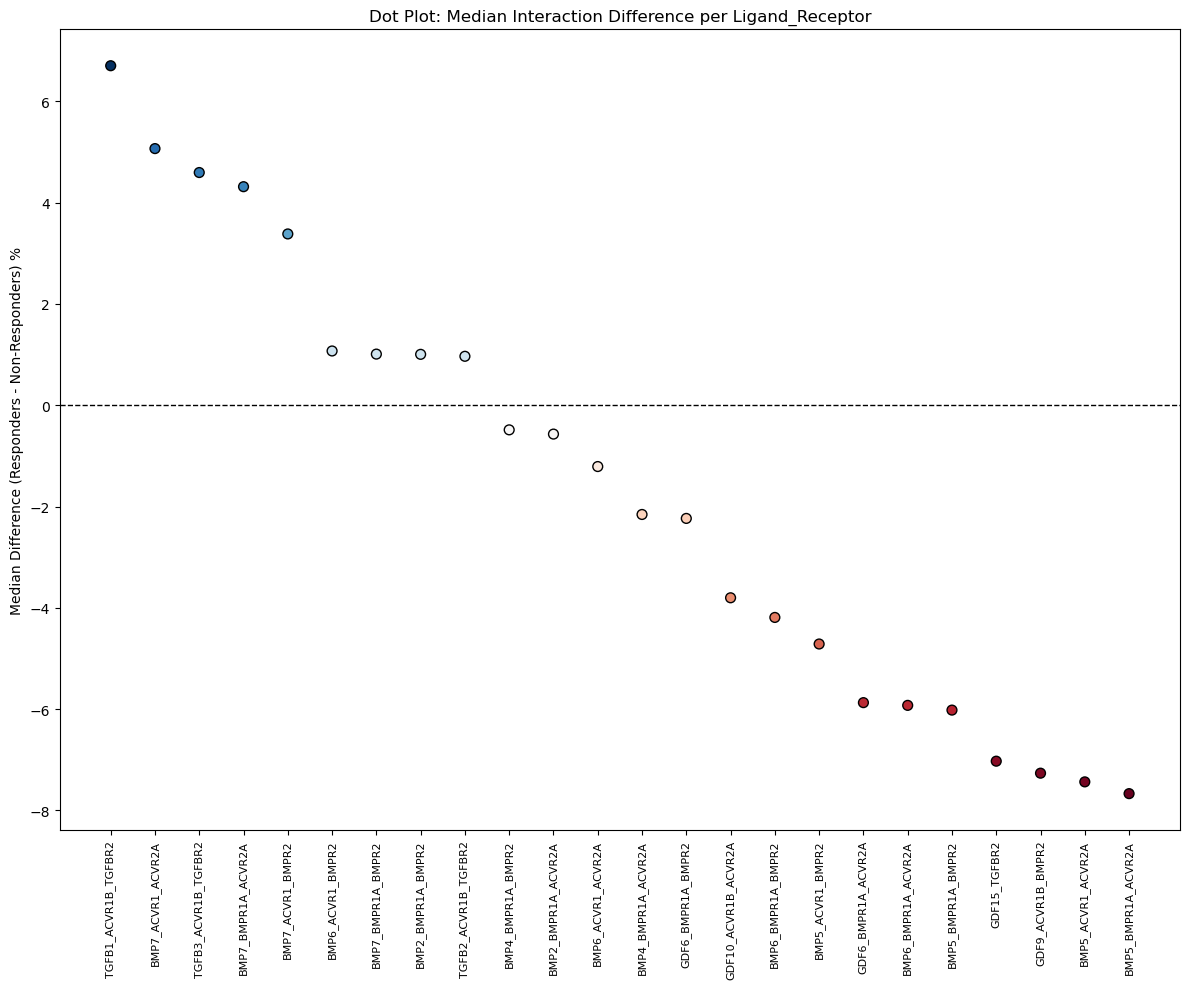

In [58]:
import matplotlib.pyplot as plt

# Prepare the data: create a "ligand_receptor" label
plot_df = output_df.copy()
plot_df["ligand_receptor"] = plot_df["ligand"] + "_" + plot_df["receptor"]

# Sort by difference for visual clarity
plot_df = plot_df.sort_values(by="difference", ascending=False)

plt.figure(figsize=(12, 10))

# Scatter plot: x = ligand_receptor, y = difference
plt.scatter(
    x=range(len(plot_df)),             # just positions on x-axis
    y=plot_df["difference"],
    c=plot_df["difference"],
    cmap="RdBu",
    s=50,
    edgecolor="k"
)

# Add x-axis labels as ligand_receptor
plt.xticks(ticks=range(len(plot_df)), labels=plot_df["ligand_receptor"], rotation=90, fontsize=8)

# Add horizontal line at 0
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.ylabel("Median Difference (Responders - Non-Responders) %")
plt.title("Dot Plot: Median Interaction Difference per Ligand_Receptor")

plt.tight_layout()
plt.show()


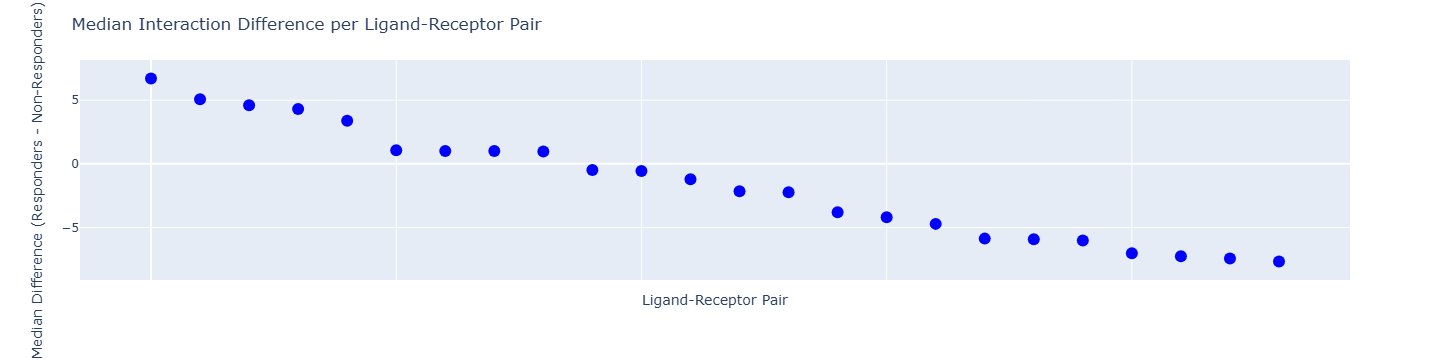

In [60]:
import plotly.express as px

# Average time to run a single pair in TMA A only 7 minutes on laptop. Probably about 18 minutes for full run
# Prepare ligand_receptor label
plot_df = output_df.copy()
plot_df["ligand_receptor"] = plot_df["ligand"] + "_" + plot_df["receptor"]

# Sort by difference descending (most positive on left)
plot_df = plot_df.sort_values(by="difference", ascending=False).reset_index(drop=True)
plot_df["x_index"] = range(len(plot_df))  # Evenly spaced x-axis

# Create scatter plot
fig = px.scatter(
    plot_df,
    x="x_index",
    y="difference",
    hover_name="ligand_receptor",   # hover shows only ligand_receptor
    color_discrete_sequence=["blue"],  # single color
)

# Increase dot size
fig.update_traces(marker=dict(size=12))  # larger dots

# Clean layout
fig.update_layout(
    title="Median Interaction Difference per Ligand-Receptor Pair",
    xaxis_title="Ligand-Receptor Pair",
    yaxis_title="Median Difference (Responders - Non-Responders) %",
    xaxis=dict(showticklabels=False),  # remove x-axis ticks
    showlegend=False
)

fig.show()
